Deep Learning Models (LSTM / BiLSTM)
**CDS6344 Social Media Computing — Amazon Reviews Sentiment Analysis**

This notebook implements:
- LSTM sentiment classifier
- BiLSTM sentiment classifier
- Comparison with Traditional ML baselines
- Full evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)

## 1. Install & Import Libraries

In [ ]:
# Run this cell in Google Colab
!pip install torch nltk scikit-learn matplotlib seaborn plotly wordcloud pandas numpy -q

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

[nltk_data] Downloading package stopwords to C:\Users\Abirami
[nltk_data]     Muthiah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Abirami
[nltk_data]     Muthiah\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to C:\Users\Abirami
[nltk_data]     Muthiah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\Abirami
[nltk_data]     Muthiah\AppData\Roaming\nltk_data...


Using device: cuda


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 2. Load & Explore Dataset

In [ ]:
# Upload the CSV to Colab, or mount Google Drive
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('Amazon_Reviews.csv', on_bad_lines='skip', engine='python')
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (21214, 9)
Columns: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


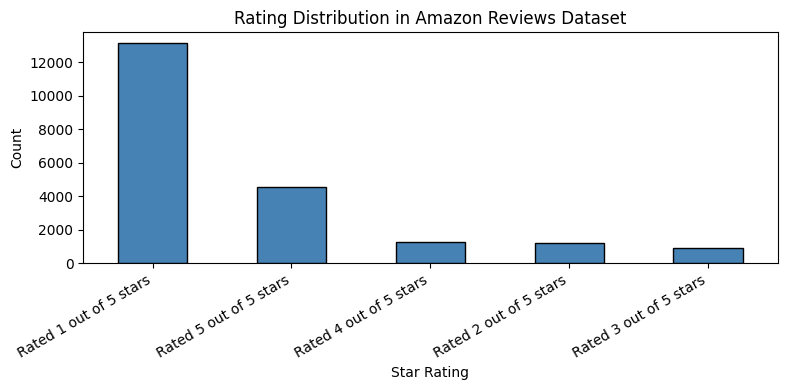

In [ ]:
# ── Rating distribution ──
plt.figure(figsize=(8,4))
df['Rating'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution in Amazon Reviews Dataset')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

## 3. Sentiment Labelling

Sentiment distribution:
Sentiment
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


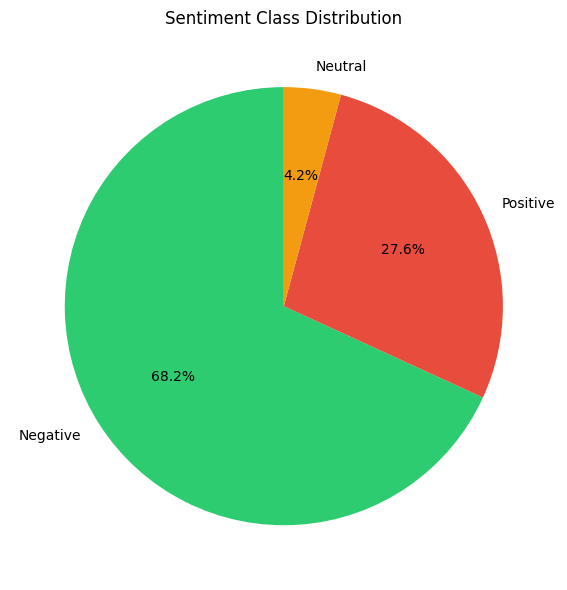

In [ ]:
def rating_to_sentiment(rating_str):
    """
    Maps raw rating strings to 3-class sentiment labels.
    1-2 stars → Negative
    3 stars   → Neutral
    4-5 stars → Positive
    """
    if pd.isna(rating_str):
        return None
    # Extract numeric part
    match = re.search(r'(\d)', str(rating_str))
    if not match:
        return None
    stars = int(match.group(1))
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)
df = df.dropna(subset=['Sentiment', 'Review Text'])
df = df[df['Review Text'].str.strip() != '']

print('Sentiment distribution:')
print(df['Sentiment'].value_counts())

# Pie chart
fig, ax = plt.subplots(figsize=(6,6))
colors = ['#2ecc71', '#e74c3c', '#f39c12']
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                     colors=colors, ax=ax, startangle=90)
ax.set_title('Sentiment Class Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('sentiment_distribution_pie.png', dpi=150)
plt.show()

## 4. Text Preprocessing

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Full preprocessing pipeline."""
    if not isinstance(text, str):
        return ''
    text = text.lower()                                    # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)            # Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)            # Remove non-ASCII (emojis etc.)
    text = re.sub(r'[^a-z\s]', '', text)                  # Remove punctuation & numbers
    tokens = word_tokenize(text)                           # Tokenize
    tokens = [t for t in tokens if t not in stop_words]   # Stopword removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # Lemmatization
    return ' '.join(tokens)

print('Preprocessing reviews...')
df['Cleaned_Text'] = df['Review Text'].apply(clean_text)
print('Done!')

# Show sample
print('\nOriginal:', df['Review Text'].iloc[0][:200])
print('Cleaned: ', df['Cleaned_Text'].iloc[0][:200])

Preprocessing reviews...
Done!

Original: I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I se
Cleaned:  registered website tried order laptop entered detail instead charging sending product froze account demanding various verification document sent said would review within hour reality week one help giv


## 5. Vocabulary & Tokenization for Deep Learning

In [ ]:
# ── Build vocabulary ──
MAX_VOCAB = 20000
MAX_LEN   = 100   # max tokens per review
EMBED_DIM = 100

# Count all words
all_words = []
for text in df['Cleaned_Text']:
    all_words.extend(text.split())

word_counts = Counter(all_words)
vocab = ['<PAD>', '<UNK>'] + [w for w, c in word_counts.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE}')

def encode(text):
    tokens = text.split()[:MAX_LEN]
    ids    = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Pad to MAX_LEN
    ids += [0] * (MAX_LEN - len(ids))
    return ids

# Encode labels
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Sentiment'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
NUM_CLASSES = len(le.classes_)

Vocabulary size: 20000
Label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


## 6. PyTorch Dataset & DataLoaders

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Stratified train/val/test split ──
X_train, X_temp, y_train, y_temp = train_test_split(
    df['Cleaned_Text'], df['Label'],
    test_size=0.2, random_state=42, stratify=df['Label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

BATCH_SIZE = 64

train_loader = DataLoader(ReviewDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ReviewDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(ReviewDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

Train: 16844  Val: 2105  Test: 2106


## 7. Model Definitions — LSTM & BiLSTM

In [ ]:
class LSTMClassifier(nn.Module):
    """
    Unidirectional LSTM for text classification.
    Architecture: Embedding → LSTM → Dropout → FC → Softmax
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                  num_layers=num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # (batch, seq, embed)
        _, (hn, _) = self.lstm(emb)          # hn: (layers, batch, hidden)
        out = self.dropout(hn[-1])           # take last layer hidden state
        return self.fc(out)


class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM — reads sequence in both directions.
    Architecture: Embedding → BiLSTM → Dropout → FC → Softmax
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm    = nn.LSTM(embed_dim, hidden_dim,
                                  num_layers=num_layers,
                                  batch_first=True,
                                  bidirectional=True,
                                  dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)  # *2 for both directions

    def forward(self, x):
        emb = self.embedding(x)
        _, (hn, _) = self.bilstm(emb)
        # Concatenate last layer forward + backward hidden states
        fwd = hn[-2]  # forward last layer
        bwd = hn[-1]  # backward last layer
        out = torch.cat([fwd, bwd], dim=1)
        out = self.dropout(out)
        return self.fc(out)


HIDDEN_DIM  = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3

lstm_model   = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, NUM_LAYERS, DROPOUT).to(device)
bilstm_model = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, NUM_LAYERS, DROPOUT).to(device)

print('LSTM params: ', sum(p.numel() for p in lstm_model.parameters()))
print('BiLSTM params:', sum(p.numel() for p in bilstm_model.parameters()))

LSTM params:  2250243
BiLSTM params: 2631555


## 8. Training Loop

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """
    Training loop with:
    - Cross-Entropy loss (handles class imbalance via weight)
    - Adam optimizer
    - Learning rate scheduler
    - Early stopping (patience=3)
    """
    # Class weights to handle imbalanced dataset (mostly negative reviews)
    class_counts = np.bincount(df['Label'])
    total        = class_counts.sum()
    weights      = torch.tensor(total / (NUM_CLASSES * class_counts), dtype=torch.float).to(device)

    criterion  = nn.CrossEntropyLoss(weight=weights)
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val_loss = float('inf')
    patience_cnt  = 0
    PATIENCE      = 3
    history       = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        # ── Validate ──
        model.eval()
        val_loss, correct, total_samples = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                val_loss += criterion(logits, y_batch).item()
                preds     = logits.argmax(dim=1)
                correct  += (preds == y_batch).sum().item()
                total_samples += y_batch.size(0)

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        val_acc   = correct    / total_samples

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {avg_train:.4f} | '
              f'Val Loss: {avg_val:.4f} | Val Acc: {val_acc:.4f}')

        scheduler.step(avg_val)

        # Early stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_cnt  = 0
            torch.save(model.state_dict(), f'best_{model.__class__.__name__}.pt')
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    return history

In [ ]:
print('=' * 50)
print('Training LSTM...')
print('=' * 50)
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=10)

Training LSTM...
Epoch 1/10 | Train Loss: 1.0905 | Val Loss: 1.0347 | Val Acc: 0.7169
Epoch 2/10 | Train Loss: 0.9386 | Val Loss: 0.8779 | Val Acc: 0.8513
Epoch 3/10 | Train Loss: 0.8936 | Val Loss: 0.8848 | Val Acc: 0.8632
Epoch 4/10 | Train Loss: 0.8834 | Val Loss: 0.9271 | Val Acc: 0.7891
Epoch 5/10 | Train Loss: 0.9289 | Val Loss: 0.9355 | Val Acc: 0.8109
Early stopping at epoch 5


In [ ]:
print('=' * 50)
print('Training BiLSTM...')
print('=' * 50)
bilstm_history = train_model(bilstm_model, train_loader, val_loader, epochs=10)

Training BiLSTM...
Epoch 1/10 | Train Loss: 0.8885 | Val Loss: 0.7476 | Val Acc: 0.8143
Epoch 2/10 | Train Loss: 0.7050 | Val Loss: 0.7977 | Val Acc: 0.7145
Epoch 3/10 | Train Loss: 0.6166 | Val Loss: 0.7426 | Val Acc: 0.7962
Epoch 4/10 | Train Loss: 0.5098 | Val Loss: 0.7639 | Val Acc: 0.8295
Epoch 5/10 | Train Loss: 0.4138 | Val Loss: 0.8465 | Val Acc: 0.8081
Epoch 6/10 | Train Loss: 0.3346 | Val Loss: 1.0565 | Val Acc: 0.8375
Early stopping at epoch 6


## 9. Training Curves Visualization

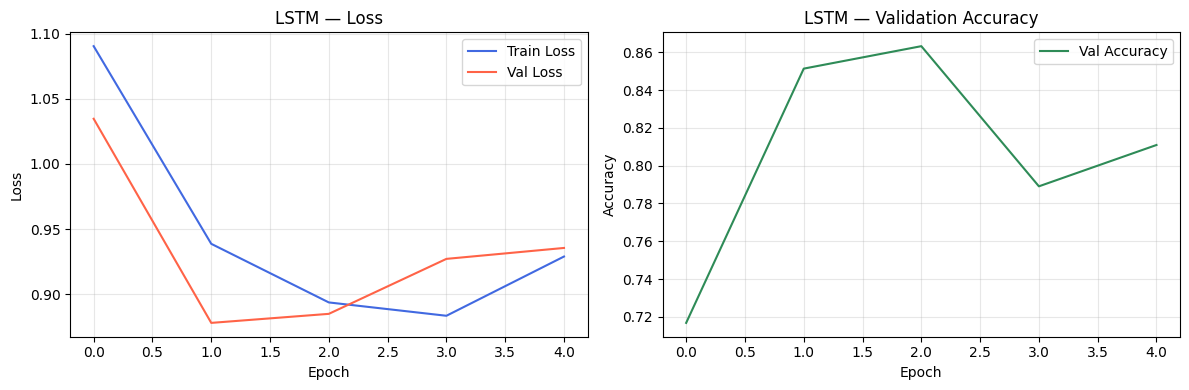

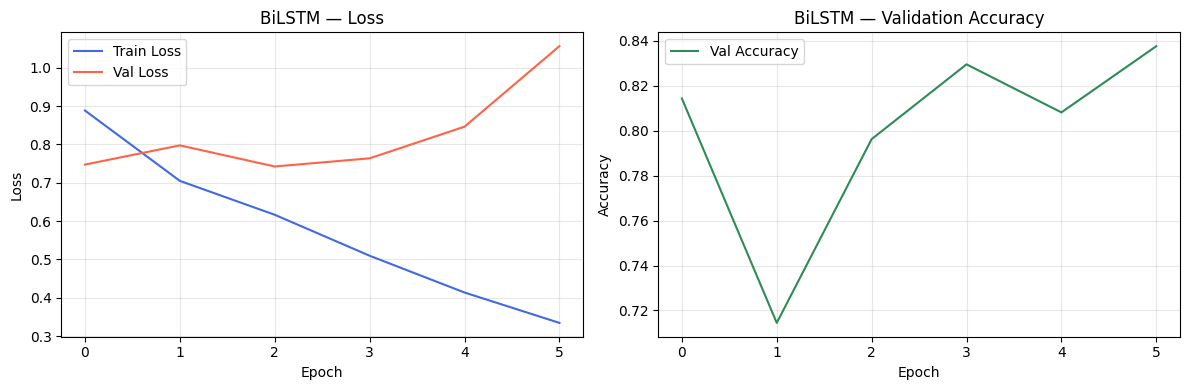

'bilstm_curves.png'

In [ ]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', color='royalblue')
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history['val_acc'], label='Val Accuracy', color='seagreen')
    axes[1].set_title(f'{title} — Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '_curves.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    return fname

plot_training_curves(lstm_history,   'LSTM')
plot_training_curves(bilstm_history, 'BiLSTM')

## 10. Evaluation on Test Set

C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_8996\2883006618.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{model.__cl


LSTM — Test Results
Accuracy : 0.8409
Precision: 0.8082
Recall   : 0.8409
F1-Score : 0.8240

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90      1435
     Neutral       0.00      0.00      0.00        89
    Positive       0.73      0.81      0.77       582

    accuracy                           0.84      2106
   macro avg       0.54      0.57      0.56      2106
weighted avg       0.81      0.84      0.82      2106



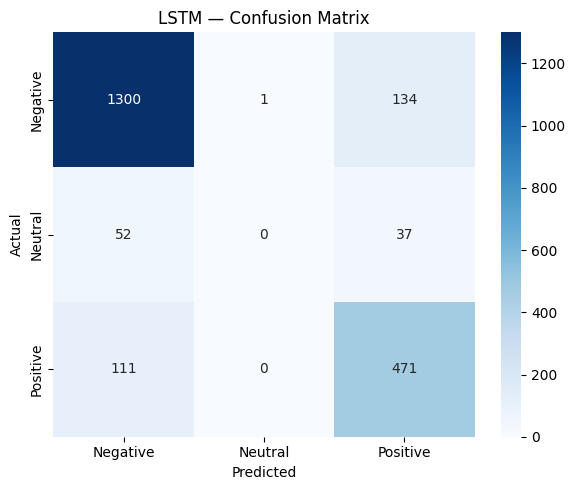

C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_8996\2883006618.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{model.__cl


BiLSTM — Test Results
Accuracy : 0.7811
Precision: 0.8588
Recall   : 0.7811
F1-Score : 0.8136

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.81      0.87      1435
     Neutral       0.13      0.43      0.20        89
    Positive       0.78      0.75      0.77       582

    accuracy                           0.78      2106
   macro avg       0.61      0.67      0.61      2106
weighted avg       0.86      0.78      0.81      2106



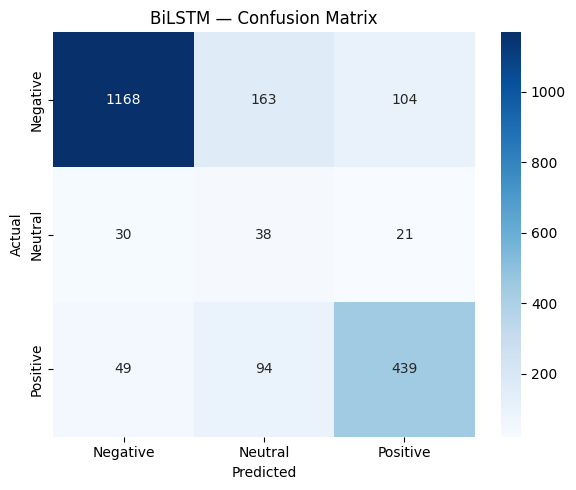

In [ ]:
def evaluate_model(model, test_loader, model_name, class_names):
    """Full test-set evaluation with all metrics."""
    # Load best checkpoint
    model.load_state_dict(torch.load(f'best_{model.__class__.__name__}.pt',
                                      map_location=device))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(device))
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)

    print(f'\n{"="*50}')
    print(f'{model_name} — Test Results')
    print(f'{"="*50}')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_confusion_matrix.png', dpi=150)
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}


class_names = list(le.classes_)
lstm_results   = evaluate_model(lstm_model,   test_loader, 'LSTM',   class_names)
bilstm_results = evaluate_model(bilstm_model, test_loader, 'BiLSTM', class_names)

## 11. Model Comparison Bar Chart

              Model  Accuracy  F1-Score
Logistic Regression  0.820000  0.810000
        Naive Bayes  0.780000  0.770000
                SVM  0.840000  0.830000
               LSTM  0.840931  0.824004
             BiLSTM  0.781102  0.813572


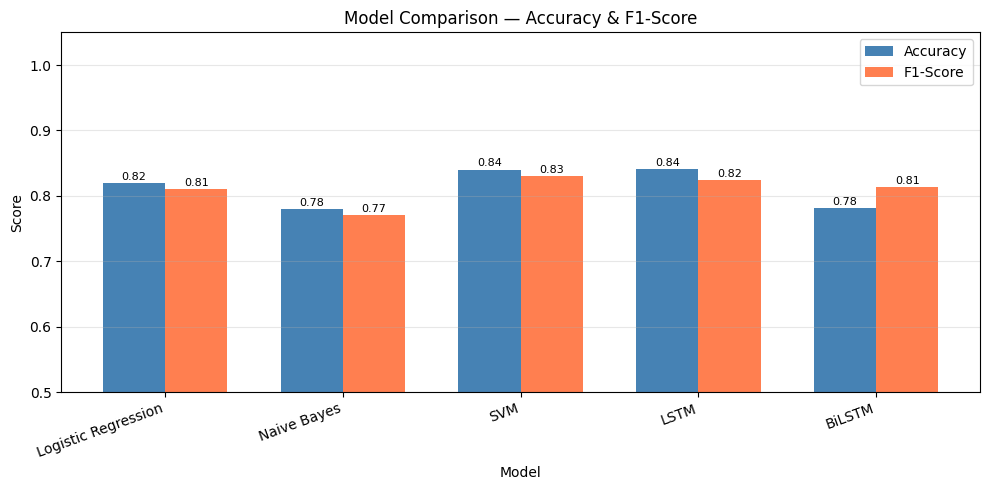

In [ ]:
# Collect results from Member 1's ML models too (paste their values here)
# Replace placeholder values with actual ones from Member 1
all_results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.82, 'F1-Score': 0.81},  # From Member 1
    {'Model': 'Naive Bayes',         'Accuracy': 0.78, 'F1-Score': 0.77},
    {'Model': 'SVM',                 'Accuracy': 0.84, 'F1-Score': 0.83},
    {'Model': 'LSTM',                'Accuracy': lstm_results['Accuracy'],   'F1-Score': lstm_results['F1-Score']},
    {'Model': 'BiLSTM',              'Accuracy': bilstm_results['Accuracy'], 'F1-Score': bilstm_results['F1-Score']},
]

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

# Grouped bar chart
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_title('Model Comparison — Accuracy & F1-Score')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (acc, f1) in enumerate(zip(results_df['Accuracy'], results_df['F1-Score'])):
    ax.text(i - width/2, acc + 0.005, f'{acc:.2f}', ha='center', fontsize=8)
    ax.text(i + width/2, f1  + 0.005, f'{f1:.2f}',  ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 12. Save All Results

In [ ]:
results_df.to_csv('dl_model_results.csv', index=False)
print('Saved: dl_model_results.csv')
print('Saved model checkpoints: best_LSTMClassifier.pt, best_BiLSTMClassifier.pt')

Saved: dl_model_results.csv
Saved model checkpoints: best_LSTMClassifier.pt, best_BiLSTMClassifier.pt
